In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from utils.data_utils import MoonsDataHelper
import warnings
from utils.evaluation_utils import EvaluationHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [1088]:
x_train, x_test, y_train, y_test = MoonsDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1600, 2), (400, 2), (1600,), (400,))

In [1089]:
x_train.head()

,Feature_1,Feature_2
1860,1.216889,-0.627630
353,1.216012,-0.401308
1333,-0.617450,1.005901
905,1.625030,-0.216752
1289,0.798015,0.056454


In [1090]:
y_train.head()

1860    1
353     1
1333    0
905     1
1289    0
Name: Class_1, dtype: int64

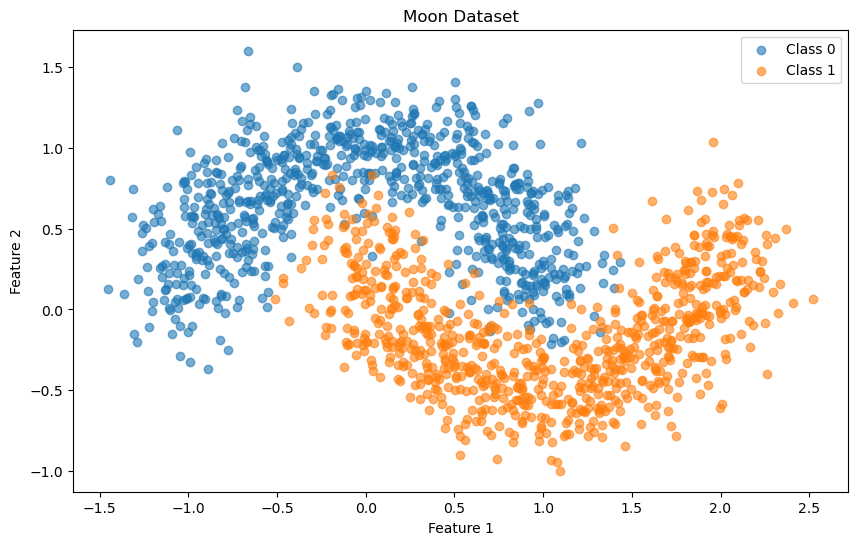

In [1091]:
MoonsDataHelper.plot_moons(x_train, y_train)

## Model Training

In [1092]:
x_train = np.array(x_train)
x_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [1093]:
y_train = np.where(y_train == 0, -1, 1)
y_test  = np.where(y_test == 0, -1, 1)

In [1094]:
alphas = np.zeros((x_train.shape[0],))
bias = 0.0

In [1095]:
def compute_similarity(x1, x2, gamma=15):
    dist_sq = np.sum((x1 - x2)**2)
    return np.exp(-gamma * dist_sq)

In [1096]:
train_size = len(x_train)

similarities = np.zeros(shape=(train_size, train_size))

for i in range(train_size):
    for j in range(train_size):
        similarity = compute_similarity(x_train[i], x_train[j])
        similarities[i][j] = similarity

In [1097]:
def decide(j):
    return sum(alphas[i] * y_train[i] * similarities[i, j] for i in range(train_size)) + bias

In [1098]:
def compute_error(i):
    return decide(i) - y_train[i]

In [1099]:
errors = np.zeros(train_size)

for i in range(train_size):
    errors[i] = compute_error(i)

In [1100]:
def update_parameters(i, j, C):
    global alphas, bias, errors
    
    kernel_dist = similarities[i][i] + similarities[j][j] - 2*similarities[i][j]
    
    if kernel_dist <= 0:
        return False
    
    if abs(errors[i] - errors[j]) < 1e-12:
        return False
    
    adjustment = y_train[j] * (errors[i] - errors[j]) / kernel_dist

    if y_train[i] != y_train[j]:
        lower_bound = max(0, alphas[j] - alphas[i])
        upper_bound = min(C, C + alphas[j] - alphas[i])
    else:
        lower_bound = max(0, alphas[i] + alphas[j] - C)
        upper_bound = min(C, alphas[i] + alphas[j])
        
    if lower_bound == upper_bound:
        return False

    new_j_alpha = alphas[j] + adjustment
    new_j_alpha = np.clip(new_j_alpha, lower_bound, upper_bound)
    
    if abs(new_j_alpha - alphas[j]) < 1e-12:
        return False

    new_i_alpha = alphas[i] + y_train[i] * y_train[j] * (alphas[j] - new_j_alpha)
    
    a1 = y_train[i] * (new_i_alpha - alphas[i]) * similarities[i][i]
    a2 = y_train[j] * (new_j_alpha - alphas[j]) * similarities[i][j]
    
    bias_1 = bias - errors[i] - a1 - a2
     
    a3 = y_train[i] * (new_i_alpha - alphas[i]) * similarities[i][j]
    a4 = y_train[j] * (new_j_alpha - alphas[j]) * similarities[j][j]
    
    bias_2 = bias - errors[j] - a3 - a4
    
    if 0 < new_i_alpha < C:
        new_bias = bias_1
    elif 0 < new_j_alpha < C:
        new_bias = bias_2
    else:
        new_bias = (bias_1 + bias_2) / 2
    
    alphas[j] = new_j_alpha
    
    alphas[i] = new_i_alpha
    bias = new_bias
    
    for k in range(train_size):
        errors[k] = compute_error(k)
    
    return True

In [1101]:
def violates_kkt(i, C, tol=1e-3):
    r = y_train[i] * errors[i]
    return (r < -tol and alphas[i] < C) or (r > tol and alphas[i] > 0)

In [1102]:
C = 1
support_threshold = 1e-5

for i in range(train_size):
    if not violates_kkt(i, C):
        continue
    
    diffs = np.abs(errors - errors[i])
    diffs[i] = -1
    
    j = np.argmax(diffs)
    success = update_parameters(i, j, C)
    
    if not success:
        j = np.random.choice([x for x in range(train_size) if x != i])
        update_parameters(i, j, C)
    
    if (i + 1) % 50 == 0:
        print(f"Sample {i + 1}/{train_size} | Updated pair: ({i}, {j})")        
    
support_indices = np.where(alphas > support_threshold)[0]

support_vectors = x_train[support_indices]
support_alphas = alphas[support_indices]
support_labels = y_train[support_indices]

print(f"Number of support vectors: {len(support_vectors)}")


Sample 50/1600 | Updated pair: (49, 454)
Sample 100/1600 | Updated pair: (99, 886)
Sample 250/1600 | Updated pair: (249, 1382)
Sample 300/1600 | Updated pair: (299, 744)
Sample 600/1600 | Updated pair: (599, 1444)
Sample 650/1600 | Updated pair: (649, 1265)
Sample 850/1600 | Updated pair: (849, 482)
Sample 1200/1600 | Updated pair: (1199, 1195)
Sample 1300/1600 | Updated pair: (1299, 1035)
Number of support vectors: 205


In [1103]:
def predict(x):
    result = sum(support_alphas[i] * support_labels[i] * compute_similarity(support_vectors[i], x) for i in range(len(support_vectors))) + bias
    return 1 if result >= 0 else 0

## Model Evaluation

In [1104]:
predictions = []

for x in x_test:
    prediction = predict(x)
    predictions.append(prediction)

predictions = np.array(predictions)

In [1105]:
y_train_binary = np.where(y_train == -1, 0, 1)
y_test_binary = np.where(y_test == -1, 0, 1)

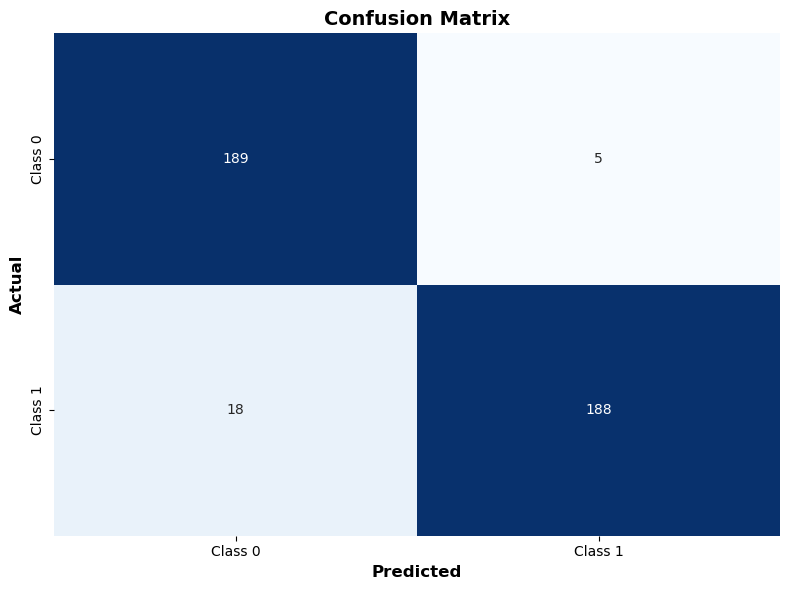

True Negatives: 189
False Positives: 5
False Negatives: 18
True Positives: 188

Sensitivity (Recall): 0.9126
Specificity: 0.9742
Precision: 0.9741
Accuracy: 0.9425
F1 Score: 0.9424


In [1106]:
EvaluationHelper.plot_confusion_matrix(y_test_binary, predictions, class_names=["Class 0", "Class 1"])

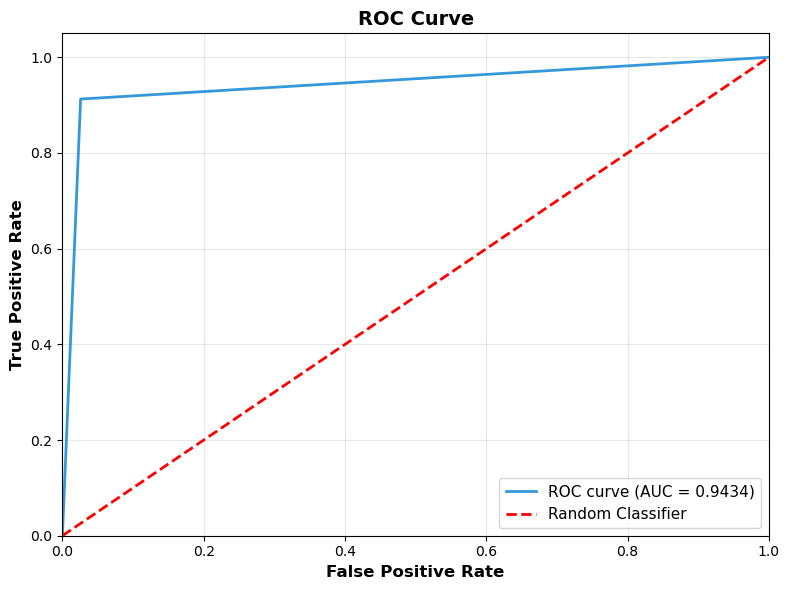

Area Under the Curve (AUC): 0.9434


In [1107]:
EvaluationHelper.plot_roc_curve(y_test_binary, predictions)

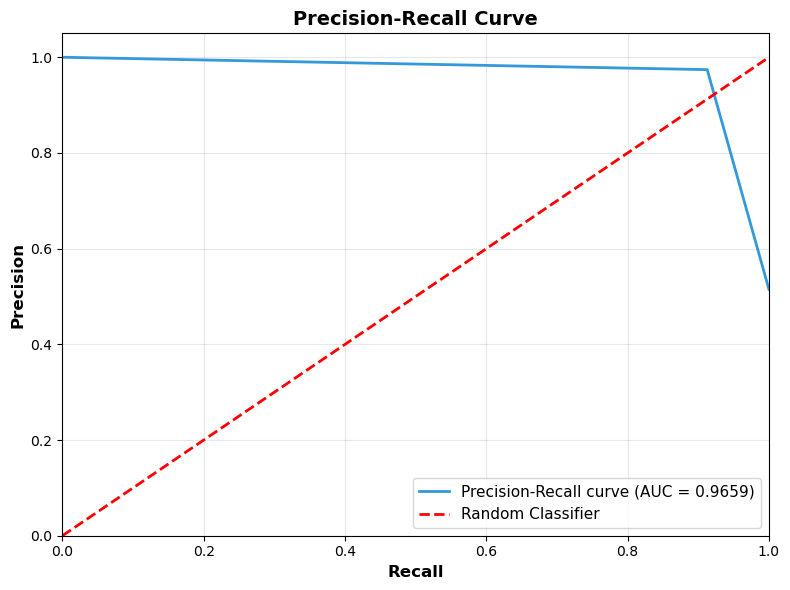

Area Under the Curve (AUC): 0.9659


In [1108]:
EvaluationHelper.plot_precision_recall_curve(y_test_binary, predictions)

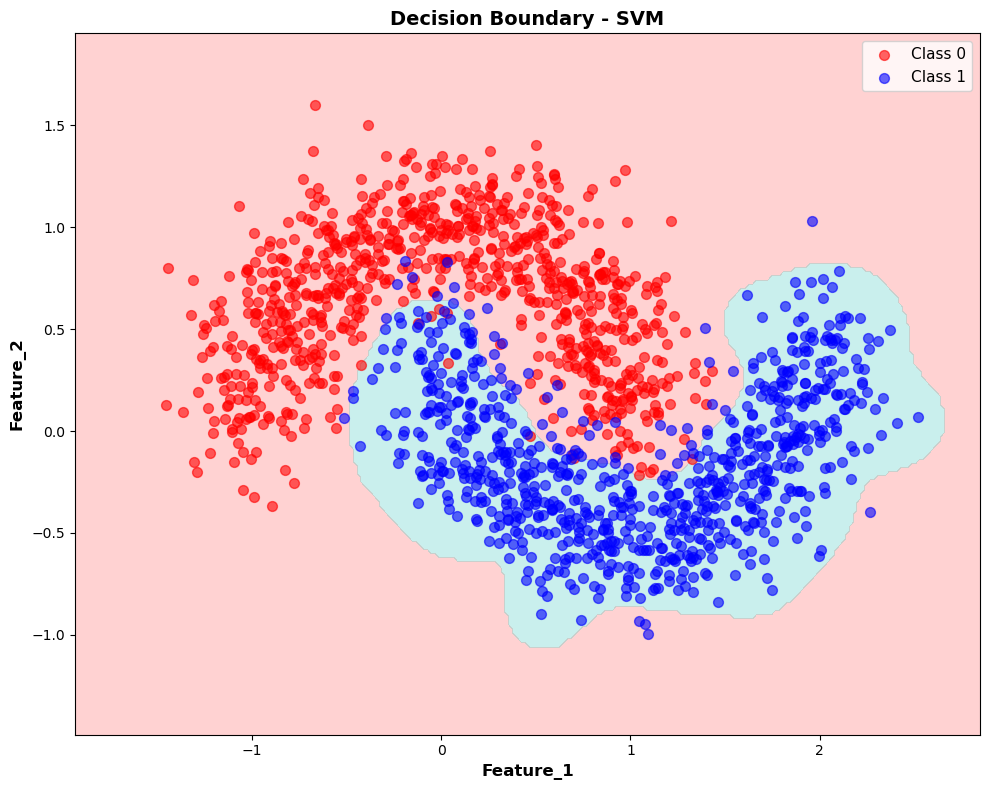

In [1109]:
h = 0.02
x_min, x_max = x_test[:, 0].min() - 0.5, x_test[:, 0].max() + 0.5
y_min, y_max = x_test[:, 1].min() - 0.5, x_test[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = np.array([predict(np.array([xx[i, j], yy[i, j]]))
              for i in range(xx.shape[0]) for j in range(xx.shape[1])])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, alpha=0.3, levels=[0, 0.5, 1], colors=['#FF6B6B', '#4ECDC4'])
ax.scatter(x_train[y_train_binary == 0, 0], x_train[y_train_binary == 0, 1], 
           c='red', marker='o', label='Class 0', alpha=0.6, s=50)
ax.scatter(x_train[y_train_binary == 1, 0], x_train[y_train_binary == 1, 1], 
           c='blue', marker='o', label='Class 1', alpha=0.6, s=50)
ax.set_xlabel('Feature_1', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature_2', fontsize=12, fontweight='bold')
ax.set_title('Decision Boundary - SVM', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()